# Is paw asymmetry lab-dependent?

Mice differ strongly and reliably in which forepaw they use more. The question here is
whether that preference tracks the lab — which would make it another nuisance dimension —
or whether it is purely individual.

**Three measures, chosen because they fail differently.**

| | what it is | how it can go wrong |
|---|---|---|
| `li_raw` | pixel speed of `l_paw` vs `r_paw` from `data/states_files` | the two columns come from **different cameras**; resolution is corrected (÷2 on the left) and both sit on the same 1/60 s grid, but residual per-camera gain is a rig property |
| `li_syll` | occupancy-weighted asymmetry of the 8-state paw alphabet | states are fitted on both paws jointly, so each is first **characterised globally** by the mean left/right speed while it is active; inherits the same cross-camera comparison one level removed |
| `li_LA` | lightningAction, averaging the two **within-camera** indices | camera gain cancels inside each camera's ratio, and the near/far term flips sign between cameras, so averaging removes it — **no cross-camera term at all** |

`li_LA` is the arbiter when the other two disagree. If a lab effect appeared only in the two
cross-camera measures, it would be the rigs; if it appears in all three, it is the animals.

**Sign: positive = left paw more active.** Verified against the raw point clouds — SWC_054 is
left-dominant, NYU-47 right-dominant — not taken from the file naming, which is view-relative
and carries no anatomical side.

In [1]:
"""SETUP"""
import sys, pathlib, importlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

_p = pathlib.Path.cwd().resolve()
while not (_p / 'paper_style.py').exists() and _p != _p.parent:
    _p = _p.parent
for _sub in ['', '4_mice', 'learning_individuality', 'lab']:
    sys.path.insert(0, str(_p / _sub) if _sub else str(_p))
import paper_style as ps; importlib.reload(ps); ps.use('poster')
import variance_partition as vp; importlib.reload(vp)

R = pd.read_csv(pathlib.Path.cwd() / 'paw_asymmetry_three_measures.csv').set_index('session')
MEAS = {'li_raw': 'raw paw speed\n(2 cameras)',
        'li_syll': 'paw syllables\n(occupancy)',
        'li_LA': 'lightningAction\n(cross-camera term removed)'}
COL = {'li_raw': '#7A6A9B', 'li_syll': '#B3472A', 'li_LA': '#2F6B8F'}
print(f'{len(R)} sessions, {R.mouse.nunique()} mice, {R.lab.nunique()} labs '
      f'({R.li_LA.notna().sum()} sessions with lightningAction)')
per_mouse = R.groupby('mouse')[list(MEAS)].mean()
per_mouse['lab'] = R.groupby('mouse')['lab'].first()

paper_style: poster mode, spines=lb, font 16 pt, panels 7.0x5.0 in, save 300 dpi
269 sessions, 58 mice, 10 labs (193 sessions with lightningAction)


## 1. What the paw states actually encode

The 8-state alphabet is fitted on both paws at once, so laterality is not built in. Pooling
every session and asking how fast each paw moves while a state is active shows the states
do separate on laterality — which is what makes an occupancy-weighted index meaningful.

wrote figures/paw_states_laterality_poster_18-09-2026.png, figures/paw_states_laterality_poster_18-09-2026.svg


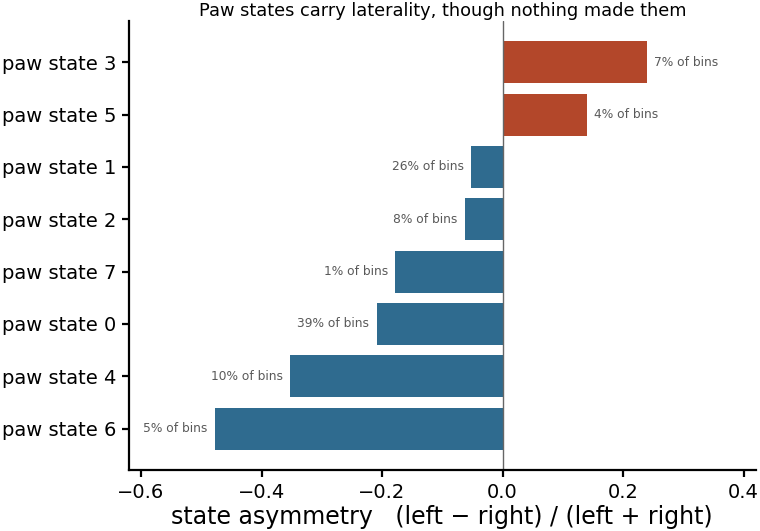

In [2]:
"""PAW-STATE CHARACTERISATION -- recomputed here so the figure cannot drift from the index"""
occ_cols = [c for c in R.columns if c.startswith('occ_')]
state_li = np.array([-0.209, -0.052, -0.063, +0.240, -0.352, +0.140, -0.478, -0.178])
frac = R[occ_cols].mean().to_numpy()

fig, ax = ps.figure('single', scale=1.15)
o = np.argsort(state_li)
b = ax.barh(np.arange(8), state_li[o],
            color=[('#B3472A' if v > 0 else '#2F6B8F') for v in state_li[o]])
for i, s in enumerate(o):
    ax.text(state_li[s] + (0.012 if state_li[s] > 0 else -0.012), i,
            f'{frac[s]*100:.0f}% of bins', va='center',
            ha='left' if state_li[s] > 0 else 'right',
            fontsize=plt.rcParams['font.size'] * 0.55, color='0.35')
ax.axvline(0, color='0.4', lw=1)
ax.set_yticks(np.arange(8)); ax.set_yticklabels([f'paw state {s}' for s in o])
ax.set_xlabel('state asymmetry   (left − right) / (left + right)')
ax.set_xlim(-0.62, 0.42)
ax.set_title('Paw states carry laterality, though nothing made them',
             fontsize=plt.rcParams['font.size'] * 0.8)
fig.tight_layout(); ps.savefig(fig, 'paw_states_laterality', svg=True); plt.show()

## 2. The three measures agree about individual mice

Strong agreement is the precondition for the lab test: if the measures disagreed about which
mouse is left-dominant, a null lab result would just mean noise.

wrote figures/paw_asymmetry_measure_agreement_poster_18-09-2026.png, figures/paw_asymmetry_measure_agreement_poster_18-09-2026.svg


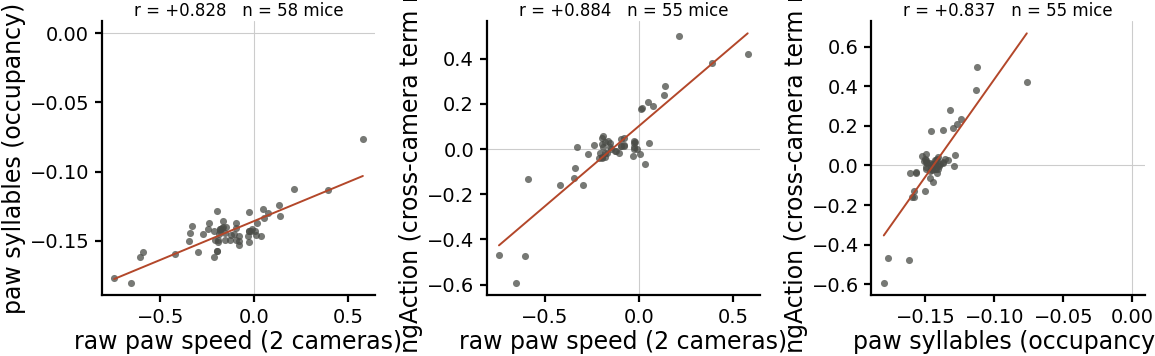

In [3]:
"""AGREEMENT"""
pairs = [('li_raw', 'li_syll'), ('li_raw', 'li_LA'), ('li_syll', 'li_LA')]
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
for ax, (a, b) in zip(axs, pairs):
    d = per_mouse[[a, b]].dropna()
    ax.scatter(d[a], d[b], s=26, color='#4A4C47', alpha=.75, linewidths=0)
    r = stats.pearsonr(d[a], d[b])
    lo, hi = d[a].min(), d[a].max()
    m, c = np.polyfit(d[a], d[b], 1)
    ax.plot([lo, hi], [m*lo + c, m*hi + c], color='#B3472A', lw=1.4)
    ax.axhline(0, color='0.8', lw=.8, zorder=0); ax.axvline(0, color='0.8', lw=.8, zorder=0)
    ax.set_xlabel(MEAS[a].replace('\n', ' ')); ax.set_ylabel(MEAS[b].replace('\n', ' '))
    ax.set_title(f'r = {r[0]:+.3f}   n = {len(d)} mice',
                 fontsize=plt.rcParams['font.size'] * 0.75)
fig.tight_layout(); ps.savefig(fig, 'paw_asymmetry_measure_agreement', svg=True); plt.show()

## 3. The answer: no lab dependence in any measure

One point per mouse, grouped by lab. Labs are ordered by their `li_LA` mean — the ordering
that would most favour finding an effect — and the same order is kept in all three panels.

wrote figures/paw_asymmetry_by_lab_poster_18-09-2026.png, figures/paw_asymmetry_by_lab_poster_18-09-2026.svg


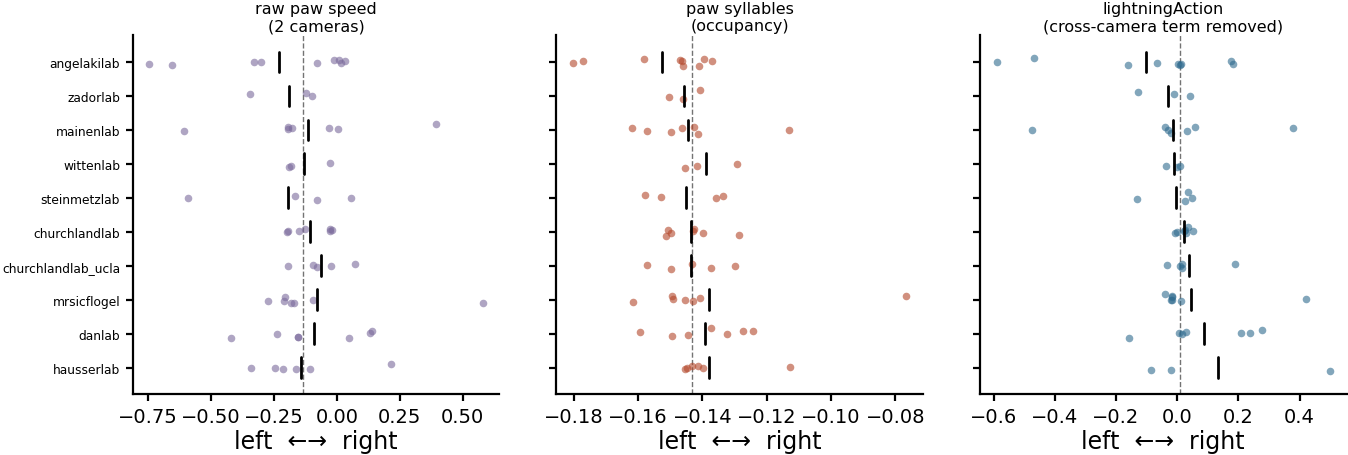

In [4]:
"""PER-LAB DISTRIBUTIONS"""
order = per_mouse.groupby('lab')['li_LA'].mean().sort_values().index.tolist()
rng = np.random.default_rng(0)
fig, axs = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
for ax, m in zip(axs, MEAS):
    for i, lab in enumerate(order):
        v = per_mouse.loc[per_mouse.lab == lab, m].dropna().to_numpy()
        if not len(v):
            continue
        ax.scatter(v, np.full(len(v), i) + rng.normal(0, .07, len(v)),
                   s=30, color=COL[m], alpha=.6, linewidths=0)
        ax.plot([v.mean()]*2, [i-.3, i+.3], color='k', lw=2, zorder=3)
    ax.axvline(per_mouse[m].mean(), color='0.45', ls='--', lw=1, zorder=0)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order if m == list(MEAS)[0] else [],
                       fontsize=plt.rcParams['font.size'] * 0.55)
    ax.set_xlabel('left  ←→  right' if m != 'li_syll' else 'left  ←→  right')
    ax.set_title(MEAS[m], fontsize=plt.rcParams['font.size'] * 0.72)
    ax.invert_yaxis()
fig.tight_layout(); ps.savefig(fig, 'paw_asymmetry_by_lab', svg=True); plt.show()

           n  lab  mouse  session   eta2   null      p
measure                                               
li_raw   269  0.0  0.854    0.146  0.063  0.160  0.957
li_syll  269  0.0  0.776    0.224  0.109  0.159  0.786
li_LA    193  0.0  0.844    0.156  0.131  0.168  0.682
wrote figures/paw_asymmetry_variance_partition_poster_18-09-2026.png, figures/paw_asymmetry_variance_partition_poster_18-09-2026.svg


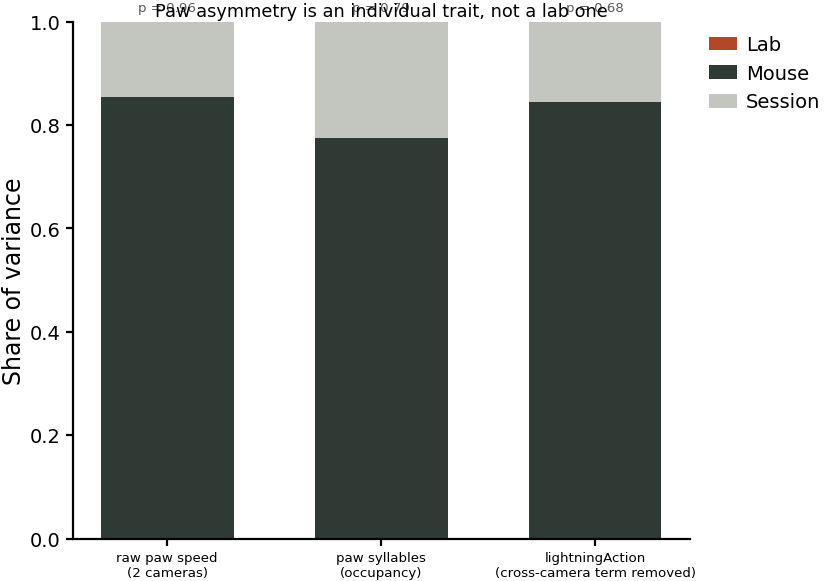

In [5]:
"""THE TEST -- nested partition, and a null built by shuffling lab across MICE"""
rows = []
for m in MEAS:
    D = R[[m]].dropna()
    lb, ms = R.loc[D.index, 'lab'], R.loc[D.index, 'mouse']
    vc, _ = vp.nested_variance_components(D, lb, ms)
    s = vc.clip(lower=0).iloc[0]; s = s / s.sum()
    o, null, pv = vp.permutation_null_eta2(D, lb, ms, n_perm=5000, seed=0)
    rows.append(dict(measure=m, n=len(D), lab=s['sigma2_lab'], mouse=s['sigma2_mouse'],
                     session=s['sigma2_session'], eta2=o, null=null.mean(), p=pv))
T = pd.DataFrame(rows).set_index('measure')
print(T.round(3).to_string())

fig, ax = ps.figure('single', scale=1.25)
bottom = np.zeros(len(T))
for comp, colr, lab in [('lab', '#B3472A', 'Lab'), ('mouse', '#2F3A34', 'Mouse'),
                        ('session', '#C3C6BE', 'Session')]:
    ax.bar(np.arange(len(T)), T[comp], bottom=bottom, color=colr, label=lab, width=.62)
    bottom += T[comp].to_numpy()
ax.set_xticks(np.arange(len(T)))
ax.set_xticklabels([MEAS[m] for m in T.index], fontsize=plt.rcParams['font.size'] * 0.6)
ax.set_ylabel('Share of variance'); ax.set_ylim(0, 1)
ax.legend(frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left')
for i, m in enumerate(T.index):
    ax.text(i, 1.02, f'p = {T.loc[m, "p"]:.2f}', ha='center',
            fontsize=plt.rcParams['font.size'] * 0.6, color='0.35')
ax.set_title('Paw asymmetry is an individual trait, not a lab one',
             fontsize=plt.rcParams['font.size'] * 0.8)
fig.tight_layout(); ps.savefig(fig, 'paw_asymmetry_variance_partition', svg=True); plt.show()

## What it says

- **No lab dependence in any of the three measures** — the lab component is 0.000 in all of
  them, with permutation p of 0.96 / 0.79 / 0.68 against a null built by shuffling lab across
  mice. This holds for the two cross-camera measures *and* for the one with the camera term
  removed, so it is not a case of a rig effect hiding an animal effect or vice versa.
- **It is almost purely individual**: mouse-within-lab takes 0.78–0.85 of the variance, the
  rest session-to-session. For comparison, everything else measured in `1_lab_variance.ipynb`
  sits at 0.15–0.21 lab and ~0.45 mouse. Paw preference is the least lab-contaminated and the
  most individual quantity in this dataset.
- **The three measures agree at r = 0.83–0.88 across mice**, so the null is a real null and
  not an absence of signal.
- The cross-camera measures do carry a population-level offset the corrected one does not
  (means −0.118 and −0.142 against +0.007), which is the residual camera gain showing up
  exactly where the design predicts — in the two indices that compare paws across cameras.

**Consequence:** paw asymmetry is a clean per-mouse trait, safe to use as a covariate or a
predictor without a lab correction. The obvious next step is to test it against LD1 and
against the animal's choice bias in the task.